<a href="https://colab.research.google.com/github/DTeklehaymanot/wafer_defect_classification/blob/main/wafer_defect_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU-Accelerated Semiconductor Wafer Defect Classification

This project develops a PyTorch computer-vision model to classify semiconductor
wafer-map failure patterns. Model training and inference will be accelerated using
an NVIDIA GPU through CUDA and benchmarked against CPU execution.

Dataset: WM-811K Wafer Map Dataset from Kaggle

In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Check whether PyTorch can access an NVIDIA GPU.
gpu_available = torch.cuda.is_available()

# Choose the GPU if available; otherwise choose the CPU.
device = torch.device("cuda" if gpu_available else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", gpu_available)
print("Selected device:", device)

# Only ask for the GPU's name if a GPU is available.
if gpu_available:
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
Selected device: cuda
GPU name: Tesla T4


In [6]:
from google.colab import drive
from pathlib import Path

# Connect Google Drive.
drive.mount("/content/drive")

# Match my existing folder names.
project_folder = Path("/content/drive/MyDrive/wafer_defect_project")

data_folder = project_folder / "Data"
checkpoint_folder = project_folder / "Checkpoints"
results_folder = project_folder / "Results"

# Check that Colab can find each folder.
for folder in [data_folder, checkpoint_folder, results_folder]:
    print(f"{folder.name}: {folder.is_dir()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data: True
Checkpoints: True
Results: True


In [7]:
# Build the path to the dataset file.
dataset_path = data_folder / "LSWMD.pkl"

# Check whether the file is accessible.
print("Dataset path:", dataset_path)
print("File found:", dataset_path.is_file())

# Display its size if it exists.
if dataset_path.is_file():
    size_mb = dataset_path.stat().st_size / (1024 ** 2)
    print(f"File size: {size_mb:.1f} MB")

Dataset path: /content/drive/MyDrive/wafer_defect_project/Data/LSWMD.pkl
File found: True
File size: 1998.4 MB


In [9]:
import pandas as pd

df = pd.read_pickle(dataset_path)

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

display(df.head(3))

Dataset loaded successfully!
Rows and columns: (811457, 6)
Column names: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]


Map shape: (45, 48)
Unique cell values: [0 1 2]
Stored label: [['none']]


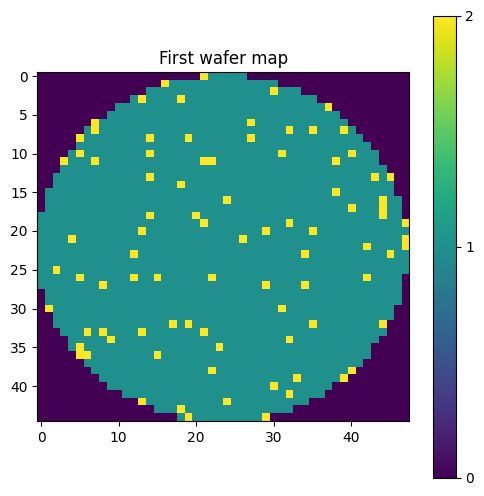

In [10]:
# Select the first row of the table.
first_wafer = df.iloc[0]

# Retrieve its wafer-map array.
wafer_map = first_wafer["waferMap"]

print("Map shape:", wafer_map.shape)
print("Unique cell values:", np.unique(wafer_map))
print("Stored label:", first_wafer["failureType"])

# Display the numerical array as an image.
plt.figure(figsize=(6, 6))
plt.imshow(
    wafer_map,
    interpolation="nearest",
    vmin=0,
    vmax=2
)
plt.title("First wafer map")
plt.colorbar(ticks=[0, 1, 2])
plt.show()